In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Preprocessing ENTSO dataset
Was scraped due to data being inconsistent with other sources. These sources were used instead.

In [2]:
path_rawdata_directory = "../datasets_raw/"

# Time series actual offshore energy production

### Total installed

In [11]:
path = "../datasets_raw/ENTSO_installed_total/"
raw_filenames = [f for f in os.listdir(path)]

year = np.array([])
installed_capacity = np.array([])

for file in raw_filenames:
    df = pd.read_csv(path + file)
    wind_offshore_df = df[df["Production Type"] == "Wind Offshore"]
    year = np.append(year, wind_offshore_df["Year"])
    installed_capacity = np.append(installed_capacity, wind_offshore_df["Installed Capacity (MW)"])

d = {"year": year, "total_installed_capacity_MW": installed_capacity}
df_total_installed_capacity = pd.DataFrame(data=d)

df_total_installed_capacity["year"] = df_total_installed_capacity["year"].astype(int)
df_total_installed_capacity["total_installed_capacity_MW"] = pd.to_numeric(df_total_installed_capacity["total_installed_capacity_MW"], errors="coerce")

print(df_total_installed_capacity)

    year  total_installed_capacity_MW
0   2014                          NaN
1   2015                        228.0
2   2016                        957.0
3   2017                        957.0
4   2018                        957.0
5   2019                        957.0
6   2020                       2460.0
7   2021                       2460.0
8   2022                       2460.0
9   2023                       4739.0
10  2024                       4739.0
11  2025                       4739.0
12  2026                       4739.0


### per windfarm

In [12]:
path = "../datasets_raw/ENTSO_installed_per_unit/"
raw_filenames = [f for f in os.listdir(path)]

dfs = []
for file in raw_filenames:
    df = pd.read_csv(path + file, header=None, skiprows=1)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# Extract start year from the date range in col 0
df["year"] = pd.to_datetime(df[0].str.split(" - ").str[0], dayfirst=True).dt.year

print(df)

# Drop rows without a known wind farm
df = df[df[4] != "NOT_FOUND"]

# Keep only relevant columns
df = df[["year", 4, 6]].rename(columns={4: "wind_farm", 6: "installed_capacity_mw"})

df_capacity_per_wind_farm = df.pivot(index="year", columns="wind_farm", values="installed_capacity_mw")
df_capacity_per_wind_farm.columns.name = None
df_capacity_per_wind_farm = df_capacity_per_wind_farm.reset_index()

print(df_capacity_per_wind_farm)

                           0       1              2                 3  \
0    01/01/2014 - 01/01/2015  BZN|NL            NaN         NOT_FOUND   
1    01/01/2014 - 01/01/2015  BZN|NL            NaN         NOT_FOUND   
2    01/01/2014 - 01/01/2015  BZN|NL            NaN         NOT_FOUND   
3    01/01/2014 - 01/01/2015  BZN|NL            NaN         NOT_FOUND   
4    01/01/2014 - 01/01/2015  BZN|NL            NaN         NOT_FOUND   
..                       ...     ...            ...               ...   
125  01/01/2026 - 01/01/2027  BZN|NL  Wind Offshore  49W000000000127W   
126  01/01/2026 - 01/01/2027  BZN|NL  Wind Offshore  49W000000000111A   
127  01/01/2026 - 01/01/2027  BZN|NL  Wind Offshore  49W000000000184K   
128  01/01/2026 - 01/01/2027  BZN|NL  Wind Offshore  49W000000000171T   
129  01/01/2026 - 01/01/2027  BZN|NL  Wind Offshore  49W000000000154T   

                                4       5       6            7    8  \
0                       NOT_FOUND     NaN   120.0   

### merge and cleanup

In [13]:
df_installed_capacity = pd.merge(df_total_installed_capacity, df_capacity_per_wind_farm, on="year", how="outer")
df_installed_capacity

,year,total_installed_capacity_MW,Borssele 1,Borssele 2,Borssele Windfarm III and IV,Hollandse Kust Zuid,OWEZ,OWF Hollandse Kust Noord,Westermeerwind,Windfarm Luchterduinen,Windfarm Princess Amalia,Windpark Gemini
0,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,228.0,NaN,NaN,NaN,NaN,108.0,NaN,NaN,NaN,NaN,NaN
2,2016,957.0,NaN,NaN,NaN,NaN,108.0,NaN,144.0,NaN,NaN,NaN
3,2017,957.0,NaN,NaN,NaN,NaN,108.0,NaN,144.0,NaN,NaN,NaN
4,2018,957.0,NaN,NaN,NaN,NaN,108.0,NaN,144.0,NaN,NaN,600.0
5,2019,957.0,NaN,NaN,NaN,NaN,108.0,NaN,144.0,NaN,NaN,600.0
6,2020,2460.0,NaN,NaN,NaN,NaN,108.0,NaN,144.0,NaN,NaN,600.0
7,2021,2460.0,376.0,376.0,NaN,NaN,108.0,NaN,144.0,NaN,NaN,600.0
8,2022,2460.0,376.0,376.0,731.5,NaN,108.0,NaN,144.0,129.0,120.0,600.0
9,2023,4739.0,376.0,376.0,731.5,1420.0,108.0,NaN,144.0,129.0,120.0,600.0


In [14]:
# drop 2014, as there is no data
df_installed_capacity = df_installed_capacity[df_installed_capacity["year"] != 2014]
# set empty fields to zero (the specific wind farm didn't exist in that year yet)
df_installed_capacity = df_installed_capacity.fillna(0)

In [15]:
df_installed_capacity

,year,total_installed_capacity_MW,Borssele 1,Borssele 2,Borssele Windfarm III and IV,Hollandse Kust Zuid,OWEZ,OWF Hollandse Kust Noord,Westermeerwind,Windfarm Luchterduinen,Windfarm Princess Amalia,Windpark Gemini
1,2015,228.0,0.0,0.0,0.0,0.0,108.0,0.0,0.0,0.0,0.0,0.0
2,2016,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,0.0
3,2017,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,0.0
4,2018,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
5,2019,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
6,2020,2460.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
7,2021,2460.0,376.0,376.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
8,2022,2460.0,376.0,376.0,731.5,0.0,108.0,0.0,144.0,129.0,120.0,600.0
9,2023,4739.0,376.0,376.0,731.5,1420.0,108.0,0.0,144.0,129.0,120.0,600.0
10,2024,4739.0,376.0,376.0,731.5,1420.0,108.0,760.0,144.0,129.0,120.0,600.0


In [16]:
print(df_installed_capacity)

    year  total_installed_capacity_MW  Borssele 1  Borssele 2  \
1   2015                        228.0         0.0         0.0   
2   2016                        957.0         0.0         0.0   
3   2017                        957.0         0.0         0.0   
4   2018                        957.0         0.0         0.0   
5   2019                        957.0         0.0         0.0   
6   2020                       2460.0         0.0         0.0   
7   2021                       2460.0       376.0       376.0   
8   2022                       2460.0       376.0       376.0   
9   2023                       4739.0       376.0       376.0   
10  2024                       4739.0       376.0       376.0   
11  2025                       4739.0       376.0       376.0   
12  2026                       4739.0       376.0       376.0   

    Borssele Windfarm III and IV  Hollandse Kust Zuid   OWEZ  \
1                            0.0                  0.0  108.0   
2                         

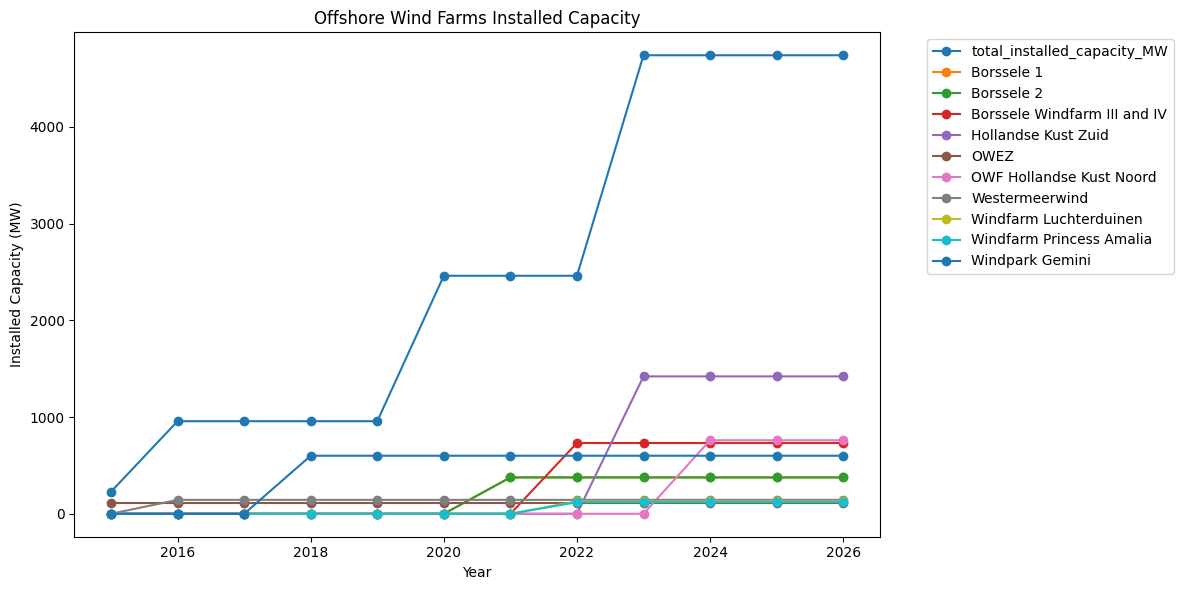

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))

for col in df_installed_capacity.columns[1:]:
    ax.plot(df_installed_capacity["year"], df_installed_capacity[col], marker="o", label=col)

ax.set_xlabel("Year")
ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Offshore Wind Farms Installed Capacity")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

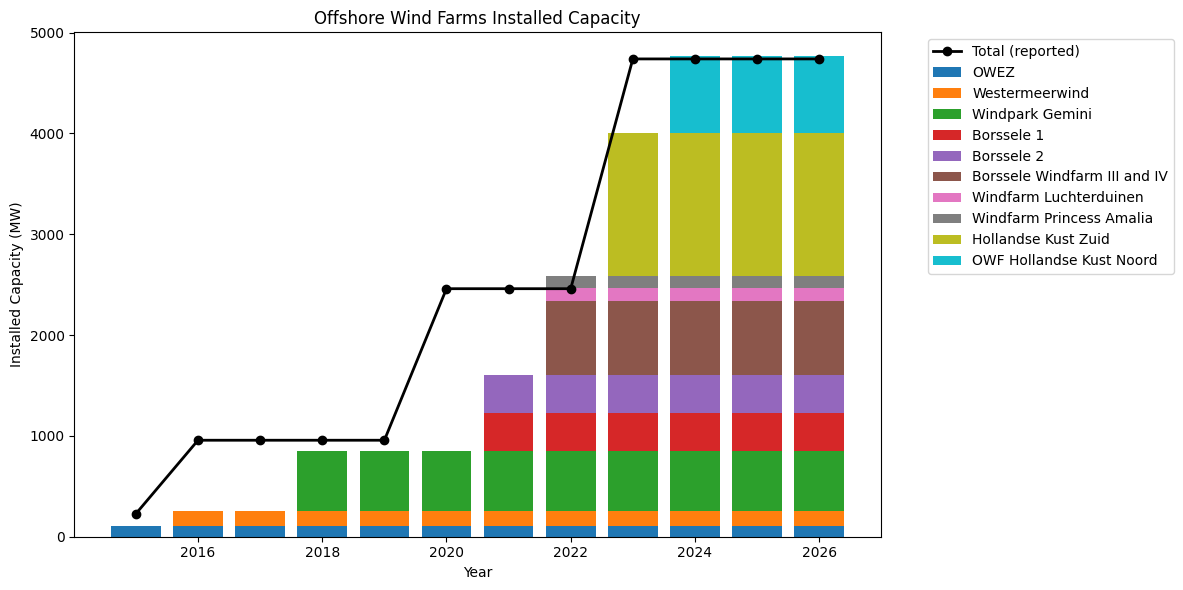

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

farm_columns = [col for col in df_installed_capacity.columns if col not in ["year", "total_installed_capacity_MW"]]
farm_columns = sorted(farm_columns, key=lambda col: df_installed_capacity[df_installed_capacity[col] > 0]["year"].min())

bottom = [0] * len(df_installed_capacity)
for col in farm_columns:
    ax.bar(df_installed_capacity["year"], df_installed_capacity[col], label=col, bottom=bottom)
    bottom = [b + v for b, v in zip(bottom, df_installed_capacity[col])]

ax.plot(df_installed_capacity["year"], df_installed_capacity["total_installed_capacity_MW"], color="black", marker="o", linewidth=2, label="Total (reported)")

ax.set_xlabel("Year")
ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Offshore Wind Farms Installed Capacity")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
df_installed_capacity

,year,total_installed_capacity_MW,Borssele 1,Borssele 2,Borssele Windfarm III and IV,Hollandse Kust Zuid,OWEZ,OWF Hollandse Kust Noord,Westermeerwind,Windfarm Luchterduinen,Windfarm Princess Amalia,Windpark Gemini
1,2015,228.0,0.0,0.0,0.0,0.0,108.0,0.0,0.0,0.0,0.0,0.0
2,2016,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,0.0
3,2017,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,0.0
4,2018,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
5,2019,957.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
6,2020,2460.0,0.0,0.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
7,2021,2460.0,376.0,376.0,0.0,0.0,108.0,0.0,144.0,0.0,0.0,600.0
8,2022,2460.0,376.0,376.0,731.5,0.0,108.0,0.0,144.0,129.0,120.0,600.0
9,2023,4739.0,376.0,376.0,731.5,1420.0,108.0,0.0,144.0,129.0,120.0,600.0
10,2024,4739.0,376.0,376.0,731.5,1420.0,108.0,760.0,144.0,129.0,120.0,600.0


In [20]:
df_installed_capacity_final = df_installed_capacity
df_installed_capacity_final["Borssele_12"] = df_installed_capacity_final["Borssele 1"] + df_installed_capacity_final["Borssele 2"]
df_installed_capacity_final = df_installed_capacity_final.drop(columns=["Borssele 1","Borssele 2"])
df_installed_capacity_final["Others"] = df_installed_capacity_final["OWEZ"] + df_installed_capacity_final["Westermeerwind"]+ df_installed_capacity_final["Windfarm Luchterduinen"]+ df_installed_capacity_final["Windfarm Princess Amalia"]
df_installed_capacity_final = df_installed_capacity_final.drop(columns=["OWEZ","Westermeerwind","Windfarm Luchterduinen","Windfarm Princess Amalia"])

df_installed_capacity_final = df_installed_capacity_final.rename(columns={"Borssele Windfarm III and IV": "Borssele_34", "Hollandse Kust Zuid": "Hollandse_Kust_Zuid", "OWF Hollandse Kust Noord": "Hollandse_Kust_Noord", "Windpark Gemini": "Gemini"})

In [21]:
df_installed_capacity_final

,year,total_installed_capacity_MW,Borssele_34,Hollandse_Kust_Zuid,Hollandse_Kust_Noord,Gemini,Borssele_12,Others
1,2015,228.0,0.0,0.0,0.0,0.0,0.0,108.0
2,2016,957.0,0.0,0.0,0.0,0.0,0.0,252.0
3,2017,957.0,0.0,0.0,0.0,0.0,0.0,252.0
4,2018,957.0,0.0,0.0,0.0,600.0,0.0,252.0
5,2019,957.0,0.0,0.0,0.0,600.0,0.0,252.0
6,2020,2460.0,0.0,0.0,0.0,600.0,0.0,252.0
7,2021,2460.0,0.0,0.0,0.0,600.0,752.0,252.0
8,2022,2460.0,731.5,0.0,0.0,600.0,752.0,501.0
9,2023,4739.0,731.5,1420.0,0.0,600.0,752.0,501.0
10,2024,4739.0,731.5,1420.0,760.0,600.0,752.0,501.0
